## **Aplicação de MLP para Classificação: Iris Dataset**

Vamos utilizar *Multilayer Perceptron (MLP)* para tarefa de classificação no [**Iris Dataset**](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html).

### **Pré-processamento dos dados**

#### **Dataset**

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

#### **Dados de Treino e Dados de Teste**

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### **Padronização dos dados**

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#### **Classe Dataset customizada**

In [4]:
import torch
import torch.nn as nn

In [5]:
from torch.utils.data import Dataset, DataLoader

class IrisDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_dataset = IrisDataset(X_train, y_train)
test_dataset  = IrisDataset(X_test,  y_test)

#### **DataLoaders**

In [6]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([16, 4])
torch.Size([16])


> [PyTorch Docs - Datasets & DataLoaders]
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

### **Implementação do Modelo**

In [7]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

class IrisNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(4, 16),
        nn.ReLU(),
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 3)
    )

  def forward(self, x):
    return self.network(x)

model = IrisNet().to(device)
print(model)

IrisNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


O modelo foi definido com a seguinte sequência de camadas:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(4,16)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{4\times16},\; \mathbf{b}^{(1)} \in \mathbb{R}^{16}},\;
    \operatorname{ReLU},\;
    \underbrace{\text{Linear}(16,16)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{16\times16},\; \mathbf{b}^{(2)} \in \mathbb{R}^{16}},\;
    \operatorname{ReLU},\;
    \underbrace{\text{Linear}(16,3)}_{\mathbf{W}^{(3)} \in \mathbb{R}^{3\times16},\; \mathbf{b}^{(3)} \in \mathbb{R}^{3}}\;
\bigr)
$$

Cada camada $\text{Linear}$ computa:

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)} + \mathbf{b}^{(\ell)}
$$

e a função de ativação é aplicada elemento a elemento:

$$
\mathbf{z}^{(\ell)} = \sigma\!\left(\mathbf{a}^{(\ell)}\right)
$$

### **Função de Treino para 1 Epoch**

In [8]:
def train(dataloader, model, loss_fn, optimizer):
  model.train()
  total_loss = 0

  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    total_loss += loss.item()

  return total_loss / len(dataloader)

### **Função de Teste**

In [9]:
def test(loader, model, loss_fn):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for X, y in loader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      total_loss += loss_fn(pred, y).item()

  n = len(loader.dataset)
  loss = total_loss/len(loader)

  return loss

## **Treinamento do Modelo**

#### **Definindo a função de perda e o otimizador**

In [10]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3
)

#### **Loop de Epochs**

In [11]:
epochs = 100
train_losses = []
test_losses  = []

for t in range(epochs):
    train_loss = train(train_loader, model, loss_fn, optimizer)
    test_loss  = test(test_loader, model, loss_fn)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (t + 1) % 10 == 0:
        print(f"Epoch {t+1:3d}/{epochs} | train: {train_loss:.4f} | test: {test_loss:.4f}")

print("\nDone!")

Epoch  10/100 | train: 0.8719 | test: 0.8203
Epoch  20/100 | train: 0.3971 | test: 0.3436
Epoch  30/100 | train: 0.2330 | test: 0.1812
Epoch  40/100 | train: 0.1503 | test: 0.1103
Epoch  50/100 | train: 0.1203 | test: 0.0791
Epoch  60/100 | train: 0.0899 | test: 0.0640
Epoch  70/100 | train: 0.0800 | test: 0.0541
Epoch  80/100 | train: 0.0718 | test: 0.0507
Epoch  90/100 | train: 0.0686 | test: 0.0477
Epoch 100/100 | train: 0.0608 | test: 0.0480

Done!


> [Arquitetura, Treino, Loop de Epochs e Validação] https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

#### **Curva de Loss**

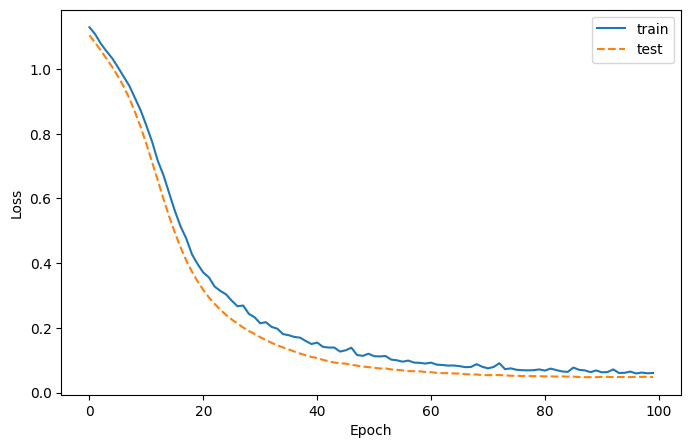

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="train")
plt.plot(test_losses,  label="test", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### **Mátricas do Modelo**

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### **Matriz de confusão**

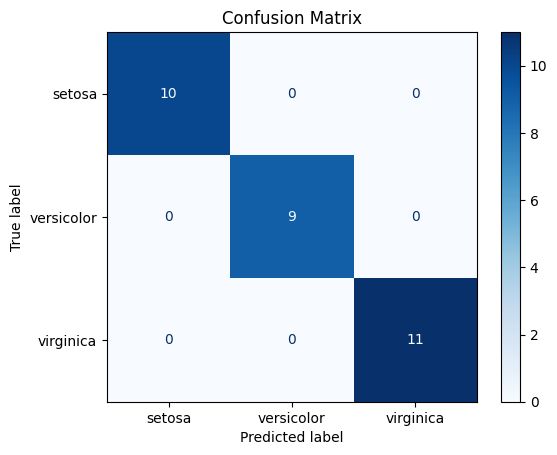

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")

plt.show()